# MovieDB Exploratory Data Analysis

**Dataset:** MovieDB movie dataset

This project explores movie trends using Python, Pandas, NumPy, Matplotlib, and Seaborn.

## 1. Project Introduction

I used Exploratory Data Analysis to understand the movie dataset before drawing any conclusions. The focus is on movie popularity, ratings, genres, languages, and release trends.

## 2. Problem Statement

The goal is to answer a few simple questions from the dataset:

- Which genres appear most often?
- Which original languages are most common?
- How have movie releases changed over the years?
- Is there a relationship between popularity, vote count, and vote average?
- Which types of movies seem to perform better?

## 3. Import Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Helper libraries
from pathlib import Path
import io
from IPython.display import display

%matplotlib inline

# Cleaner table and chart display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)

## 4. Load Dataset

In [2]:
# Load the dataset. The Python engine handles long overview text more safely.
possible_paths = [
    Path("mymoviedb.csv"),
    Path("mymoviedb(1).csv"),
    Path("../mymoviedb.csv"),
    Path("../mymoviedb(1).csv"),
    Path("/mnt/data/mymoviedb.csv"),
    Path("/mnt/data/mymoviedb(1).csv"),
]

dataset_path = None
for path in possible_paths:
    if path.exists():
        dataset_path = path
        break

if dataset_path is None:
    raise FileNotFoundError("Dataset file was not found. Please place mymoviedb.csv near this notebook.")

movies_raw = pd.read_csv(dataset_path, engine="python")

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 5. Dataset Overview

In [3]:
# Display the first five rows
print("First 5 rows:")
display(movies_raw.head())

# Display the last five rows
print("Last 5 rows:")
display(movies_raw.tail())

# Display shape of dataset
print("Dataset shape:", movies_raw.shape)

# Display column names
print("Column names:")
print(movies_raw.columns.tolist())

# Display dataset information clearly
print("\nDataset info:")
buffer = io.StringIO()
movies_raw.info(buf=buffer)
print(buffer.getvalue())

# Display descriptive statistics
print("Descriptive statistics:")
display(movies_raw.describe(include="all").T)

First 5 rows:


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


Last 5 rows:


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
9832,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9833,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9834,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9835,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...
9836,1984-09-23,Threads,Documentary style account of a nuclear holocau...,13.354,186,7.8,en,"War, Drama, Science Fiction",https://image.tmdb.org/t/p/original/lBhU4U9Eeh...


Dataset shape: (9837, 9)
Column names:
['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count', 'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url']

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   str    
 1   Title              9828 non-null   str    
 2   Overview           9828 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   str    
 5   Vote_Average       9827 non-null   str    
 6   Original_Language  9827 non-null   str    
 7   Genre              9826 non-null   str    
 8   Poster_Url         9826 non-null   str    
dtypes: float64(1), str(8)
memory usage: 4.5 MB

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Release_Date,9837,5903,2022-03-10,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,9828,9514,Beauty and the Beast,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Overview,9828,9823,"Alien pods come to Earth and, naturally, start...",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Popularity,9827.0,NaN,NaN,NaN,40.32057,108.874308,7.1,16.1275,21.191,35.1745,5083.954
Vote_Count,9827,3267,0,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vote_Average,9827,75,6.4,435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Original_Language,9827,44,en,7569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genre,9826,2337,Drama,466,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Poster_Url,9826,9826,https://image.tmdb.org/t/p/original/1g0dhYtq4i...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Data Cleaning

I cleaned the dataset with the steps needed for reliable analysis:

- Standardize column names
- Check missing values
- Remove duplicate rows
- Convert date and numeric columns
- Handle missing or invalid rows
- Detect outliers using boxplots
- Handle simple outliers using the IQR method

In [4]:
# Create a copy so the original dataset remains unchanged
movies = movies_raw.copy()

# Standardize column names: lowercase and replace spaces with underscores
old_columns = movies.columns.tolist()
movies.columns = (
    movies.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

column_changes = pd.DataFrame({
    "old_column_name": old_columns,
    "new_column_name": movies.columns.tolist()
})
display(column_changes)

# Check missing values before cleaning
print("Missing values before cleaning:")
display(movies.isnull().sum().to_frame("missing_values"))

# Check duplicate rows
duplicate_count = movies.duplicated().sum()
print("Duplicate rows before cleaning:", duplicate_count)

# Remove duplicate rows
movies = movies.drop_duplicates()
print("Shape after removing duplicates:", movies.shape)

,old_column_name,new_column_name
0,Release_Date,release_date
1,Title,title
2,Overview,overview
3,Popularity,popularity
4,Vote_Count,vote_count
5,Vote_Average,vote_average
6,Original_Language,original_language
7,Genre,genre
8,Poster_Url,poster_url


Missing values before cleaning:


,missing_values
release_date,0
title,9
overview,9
popularity,10
vote_count,10
vote_average,10
original_language,10
genre,11
poster_url,11


Duplicate rows before cleaning: 0
Shape after removing duplicates: (9837, 9)


In [5]:
# Convert release_date to datetime format
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")

# Convert numeric columns from object/string to numeric values
numeric_columns = ["popularity", "vote_count", "vote_average"]
for column in numeric_columns:
    movies[column] = pd.to_numeric(movies[column], errors="coerce")

print("Data types after conversion:")
display(movies.dtypes.to_frame("data_type"))

print("Missing values after type conversion:")
display(movies.isnull().sum().to_frame("missing_values"))

Data types after conversion:

,data_type
release_date,datetime64[us]
title,str
overview,str
popularity,float64
vote_count,float64
vote_average,float64
original_language,str
genre,str
poster_url,str


Missing values after type conversion:


,missing_values
release_date,10
title,9
overview,9
popularity,10
vote_count,11
vote_average,11
original_language,10
genre,11
poster_url,11


In [6]:
# Remove rows missing fields needed for analysis.
important_columns = [
    "release_date",
    "title",
    "popularity",
    "vote_count",
    "vote_average",
    "original_language",
    "genre",
    "poster_url",
]

rows_before = movies.shape[0]
movies = movies.dropna(subset=important_columns).copy()

# Fill any missing overview text.
movies["overview"] = movies["overview"].fillna("No overview available")

rows_after = movies.shape[0]
print("Rows removed due to missing or invalid important values:", rows_before - rows_after)
print("Final shape after missing value handling:", movies.shape)

print("Missing values after cleaning:")
display(movies.isnull().sum().to_frame("missing_values"))

Rows removed due to missing or invalid important values: 11
Final shape after missing value handling: (9826, 9)
Missing values after cleaning:


,missing_values
release_date,0
title,0
overview,0
popularity,0
vote_count,0
vote_average,0
original_language,0
genre,0
poster_url,0


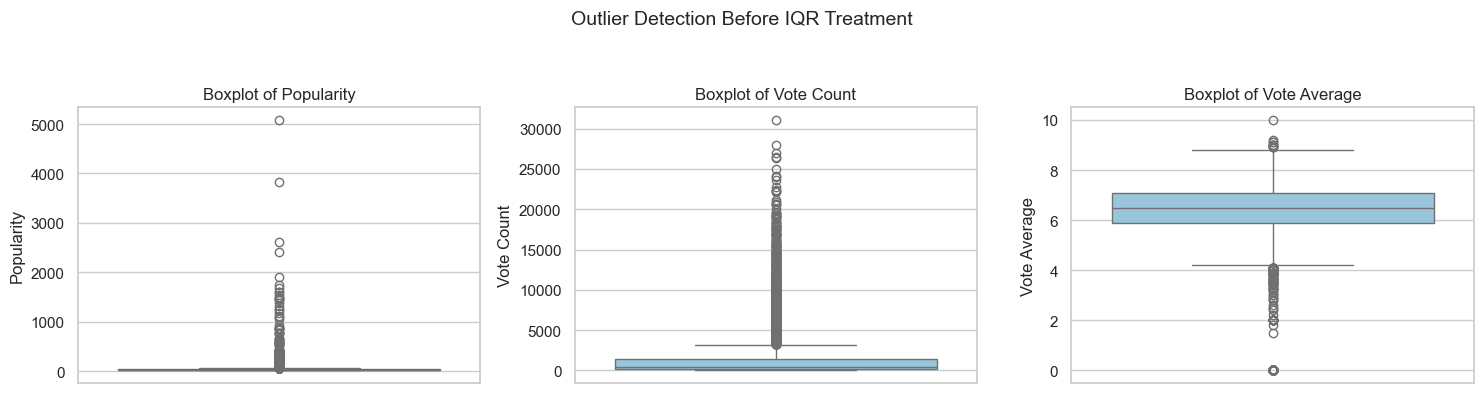

,column,q1,q3,iqr,lower_limit,upper_limit,outliers_found
0,popularity,16.12825,35.17925,19.051,-12.44825,63.75575,1047
1,vote_count,146.00000,1376.00000,1230.000,-1699.00000,3221.00000,1129
2,vote_average,5.90000,7.10000,1.200,4.10000,8.90000,243


In [7]:
# Detect outliers using boxplots
outlier_columns = ["popularity", "vote_count", "vote_average"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for index, column in enumerate(outlier_columns):
    sns.boxplot(y=movies[column], ax=axes[index], color="#8ecae6")
    axes[index].set_title(f"Boxplot of {column.replace('_', ' ').title()}")
    axes[index].set_ylabel(column.replace("_", " ").title())

plt.suptitle("Outlier Detection Before IQR Treatment", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# Create an outlier report using the IQR method
outlier_report = []
outlier_limits = {}

for column in outlier_columns:
    q1 = movies[column].quantile(0.25)
    q3 = movies[column].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outlier_count = ((movies[column] < lower_limit) | (movies[column] > upper_limit)).sum()

    outlier_limits[column] = (lower_limit, upper_limit)
    outlier_report.append({
        "column": column,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_limit": lower_limit,
        "upper_limit": upper_limit,
        "outliers_found": int(outlier_count),
    })

outlier_report_df = pd.DataFrame(outlier_report)
display(outlier_report_df)

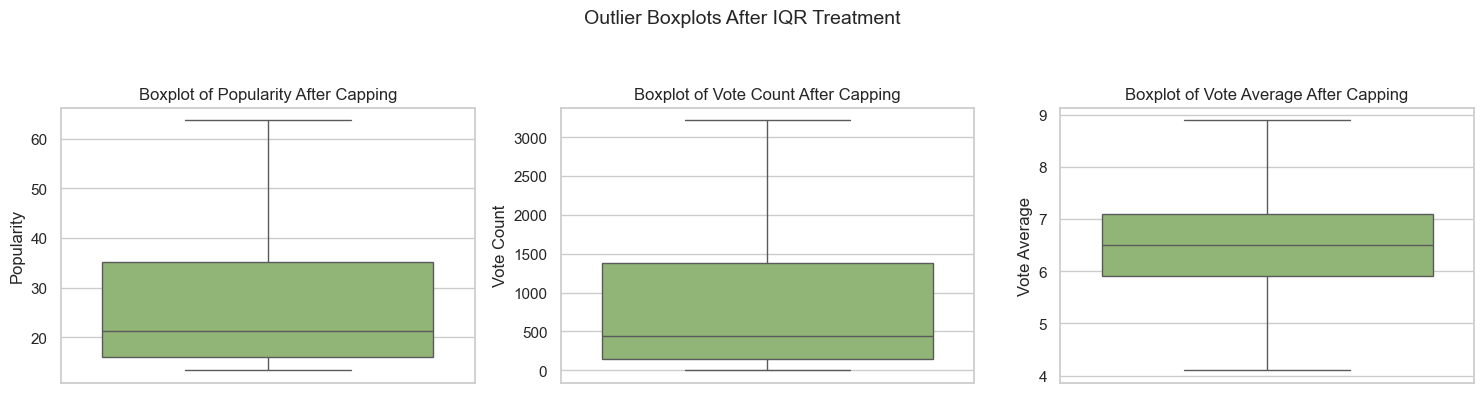

Outliers were handled using IQR capping.
Original cleaned data shape: (9826, 9)
EDA data shape after capping: (9826, 9)


In [8]:
# Cap extreme values with the IQR method.
eda_df = movies.copy()

for column in outlier_columns:
    lower_limit, upper_limit = outlier_limits[column]
    eda_df[column] = eda_df[column].clip(lower=lower_limit, upper=upper_limit)

# Check boxplots again after capping
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for index, column in enumerate(outlier_columns):
    sns.boxplot(y=eda_df[column], ax=axes[index], color="#90be6d")
    axes[index].set_title(f"Boxplot of {column.replace('_', ' ').title()} After Capping")
    axes[index].set_ylabel(column.replace("_", " ").title())

plt.suptitle("Outlier Boxplots After IQR Treatment", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print("Outliers were handled using IQR capping.")
print("Original cleaned data shape:", movies.shape)
print("EDA data shape after capping:", eda_df.shape)

**Observation:** Popularity and vote count have several high values, which is expected because a few movies receive much more attention than the rest. I used IQR capping so these extreme values do not dominate the analysis.

## 7. Feature Engineering

In [9]:
# Create useful features from existing columns.
eda_df["release_year"] = eda_df["release_date"].dt.year
eda_df["release_month"] = eda_df["release_date"].dt.month

# Text length features
eda_df["title_length"] = eda_df["title"].astype(str).str.len()
eda_df["overview_length"] = eda_df["overview"].astype(str).str.len()

# Use the first listed genre as the primary genre.
eda_df["primary_genre"] = eda_df["genre"].str.split(",").str[0].str.strip()

print("New features created:")
print(["release_year", "release_month", "title_length", "overview_length", "primary_genre"])

display(eda_df[[
    "title",
    "release_date",
    "release_year",
    "release_month",
    "title_length",
    "overview_length",
    "primary_genre",
]].head())

New features created:
['release_year', 'release_month', 'title_length', 'overview_length', 'primary_genre']


,title,release_date,release_year,release_month,title_length,overview_length,primary_genre
0,Spider-Man: No Way Home,2021-12-15,2021,12,23,258,Action
1,The Batman,2022-03-01,2022,3,10,162,Crime
2,No Exit,2022-02-25,2022,2,7,259,Thriller
3,Encanto,2021-11-24,2021,11,7,520,Animation
4,The King's Man,2021-12-22,2021,12,14,155,Action


## 8. Exploratory Data Analysis

In [10]:
# Summary statistics for numerical columns
numerical_features = [
    "popularity",
    "vote_count",
    "vote_average",
    "release_year",
    "release_month",
    "title_length",
    "overview_length",
]

print("Summary statistics for numerical features:")
display(eda_df[numerical_features].describe().T)

# Summary for categorical columns
print("Summary for categorical features:")
display(eda_df[["original_language", "primary_genre"]].describe().T)

Summary statistics for numerical features:


,count,mean,std,min,25%,50%,75%,max
popularity,9826.0,28.355677,16.335131,13.354,16.12825,21.195,35.17925,63.75575
vote_count,9826.0,944.347547,1070.969207,0.000,146.00000,444.000,1376.00000,3221.00000
vote_average,9826.0,6.489558,0.923617,4.100,5.90000,6.500,7.10000,8.90000
release_year,9826.0,2006.202931,15.686202,1902.000,2000.00000,2011.000,2017.00000,2024.00000
release_month,9826.0,6.829025,3.435731,1.000,4.00000,7.000,10.00000,12.00000
title_length,9826.0,17.341339,10.521927,1.000,10.00000,15.000,22.00000,104.00000
overview_length,9826.0,285.159475,153.004623,13.000,164.00000,250.000,375.00000,1000.00000


Summary for categorical features:


,count,unique,top,freq
original_language,9826,43,en,7569
primary_genre,9826,19,Drama,1791


In [11]:
# Distribution analysis
print("Distribution summary for key movie metrics:")
display(eda_df[["popularity", "vote_average", "vote_count"]].agg(["mean", "median", "std", "min", "max"]).T)

# Category analysis: top genres and languages
all_genres = eda_df["genre"].str.split(",").explode().str.strip()
top_genres = all_genres.value_counts().head(10)
top_languages = eda_df["original_language"].value_counts().head(10)

print("Top 10 genres:")
display(top_genres.to_frame("movie_count"))

print("Top 10 original languages:")
display(top_languages.to_frame("movie_count"))

# Trend analysis: movies released by year
yearly_movies = (
    eda_df.groupby("release_year")
    .size()
    .reset_index(name="movie_count")
    .sort_values("release_year")
)

print("Recent yearly release trend:")
display(yearly_movies.tail(10))

Distribution summary for key movie metrics:


,mean,median,std,min,max
popularity,28.355677,21.195,16.335131,13.354,63.75575
vote_average,6.489558,6.500,0.923617,4.100,8.90000
vote_count,944.347547,444.000,1070.969207,0.000,3221.00000


Top 10 genres:


,movie_count
genre,
Drama,3744
Comedy,3031
Action,2686
Thriller,2488
Adventure,1853
Romance,1476
Horror,1470
Animation,1438
Family,1414


Top 10 original languages:


,movie_count
original_language,
en,7569
ja,645
es,339
fr,292
ko,170
zh,129
it,123
cn,109
ru,83


Recent yearly release trend:


,release_year,movie_count
92,2015,390
93,2016,470
94,2017,510
95,2018,530
96,2019,500
97,2020,453
98,2021,714
99,2022,208
100,2023,8
101,2024,1


## 9. Visualizations

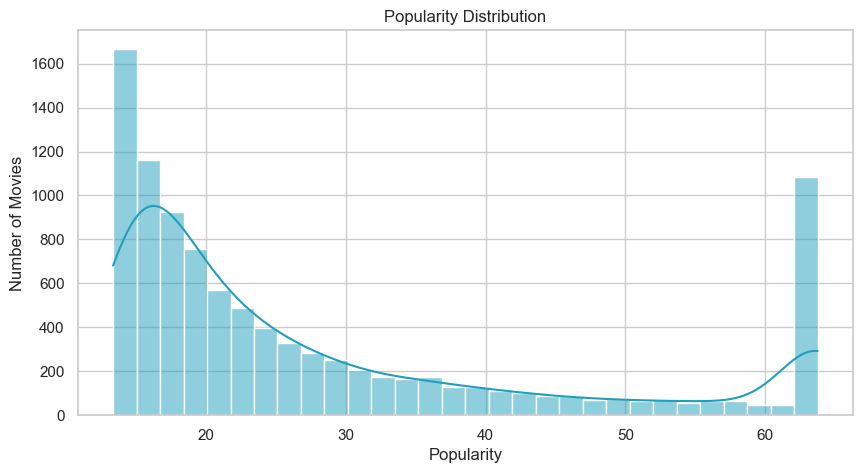

In [12]:
# Histogram: popularity distribution
plt.figure(figsize=(10, 5))
sns.histplot(eda_df["popularity"], bins=30, kde=True, color="#219ebc")
plt.title("Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Number of Movies")
plt.show()

**Observation:** Most movies sit in the lower popularity range, while a small number of titles stand out with much higher popularity.

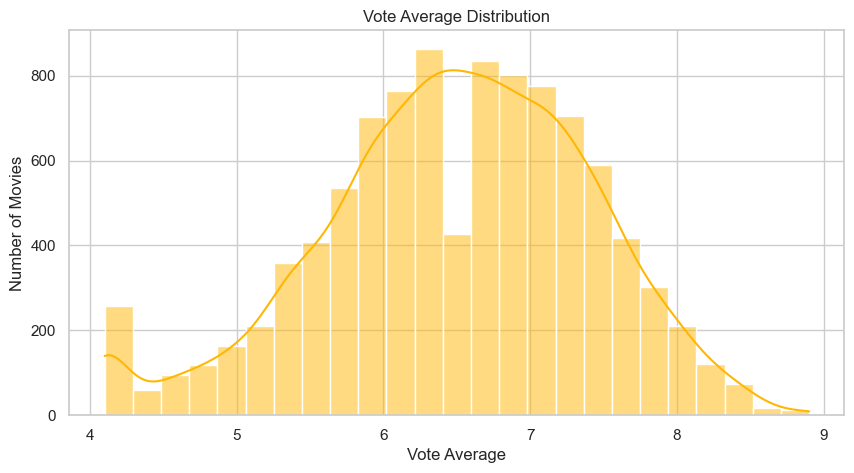

In [13]:
# Histogram: vote average distribution
plt.figure(figsize=(10, 5))
sns.histplot(eda_df["vote_average"], bins=25, kde=True, color="#ffb703")
plt.title("Vote Average Distribution")
plt.xlabel("Vote Average")
plt.ylabel("Number of Movies")
plt.show()

**Observation:** Most vote averages are around the middle range, so the dataset is mostly made up of moderately rated movies.

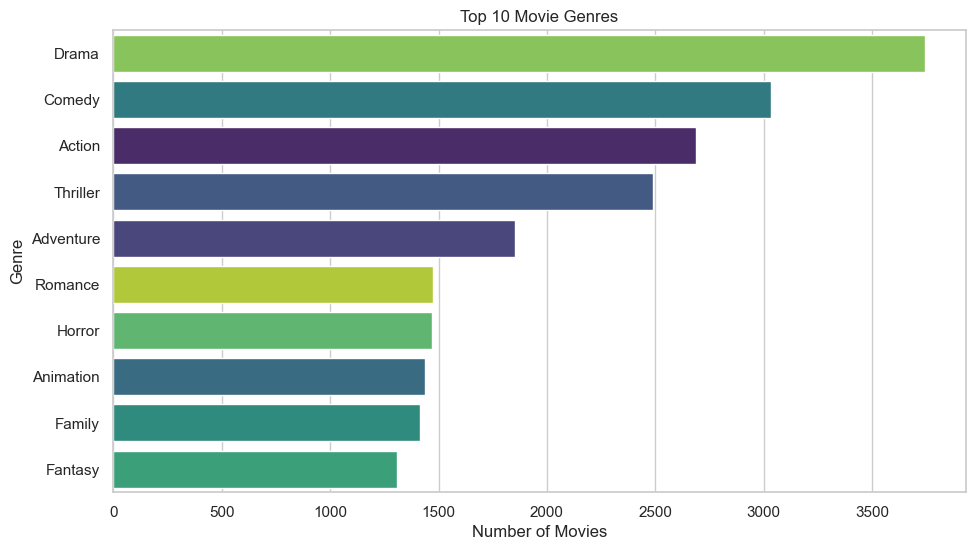

In [14]:
# Countplot: top genres
top_genre_names = top_genres.index.tolist()
genre_plot_df = pd.DataFrame({"genre": all_genres})
genre_plot_df = genre_plot_df[genre_plot_df["genre"].isin(top_genre_names)]

plt.figure(figsize=(11, 6))
sns.countplot(data=genre_plot_df, y="genre", hue="genre", order=top_genre_names, palette="viridis", legend=False)
plt.title("Top 10 Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()

**Observation:** Drama, Comedy, Action, and Thriller appear most often, which makes them the main genres in this dataset.

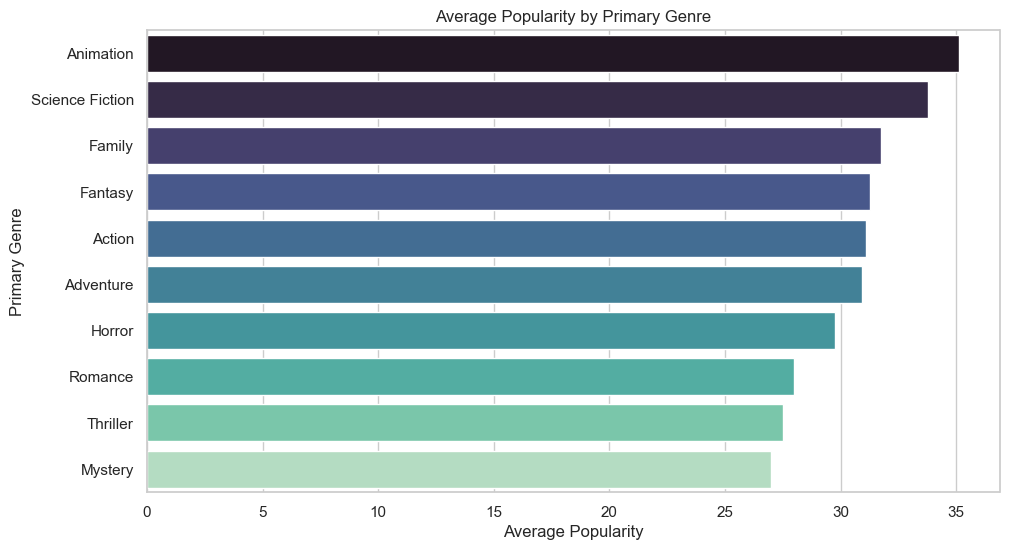

In [15]:
# Bar chart: average popularity by primary genre
avg_popularity_by_genre = (
    eda_df.groupby("primary_genre")["popularity"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=avg_popularity_by_genre,
    x="popularity",
    y="primary_genre",
    hue="primary_genre",
    palette="mako",
    legend=False,
)
plt.title("Average Popularity by Primary Genre")
plt.xlabel("Average Popularity")
plt.ylabel("Primary Genre")
plt.show()

**Observation:** Action, Animation, and Science Fiction movies show stronger average popularity than many other genres.

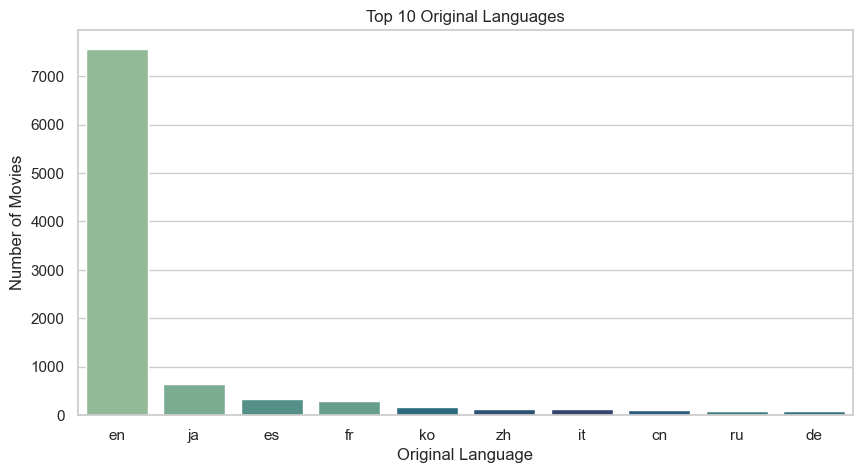

In [16]:
# Countplot: most common original languages
language_order = top_languages.index.tolist()

plt.figure(figsize=(10, 5))
sns.countplot(
    data=eda_df[eda_df["original_language"].isin(language_order)],
    x="original_language",
    hue="original_language",
    order=language_order,
    palette="crest",
    legend=False,
)
plt.title("Top 10 Original Languages")
plt.xlabel("Original Language")
plt.ylabel("Number of Movies")
plt.show()

**Observation:** English is the dominant original language. Japanese, Spanish, and French appear next but with much smaller counts.

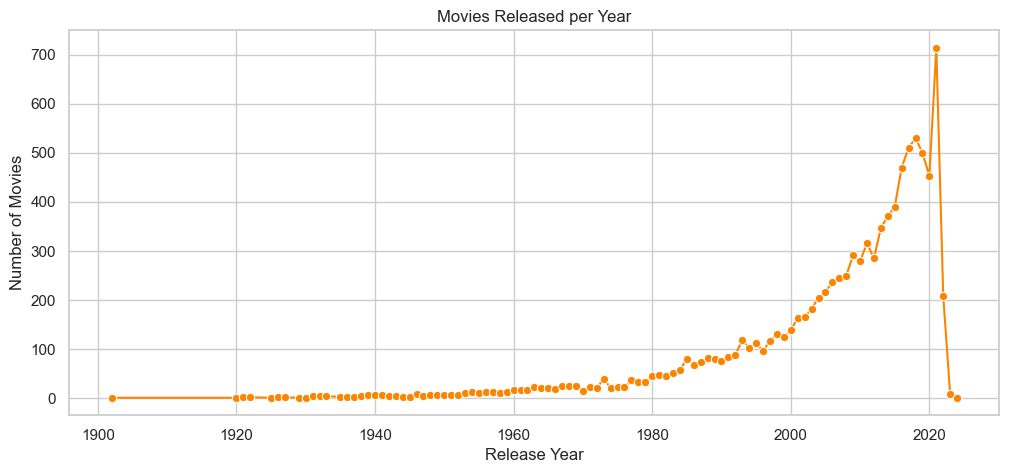

In [17]:
# Line chart: movies released per year
plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly_movies, x="release_year", y="movie_count", marker="o", color="#fb8500")
plt.title("Movies Released per Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.show()

**Observation:** Movie releases rise clearly from the 2000s onward. The last few years may be lower because the dataset may not be fully updated.

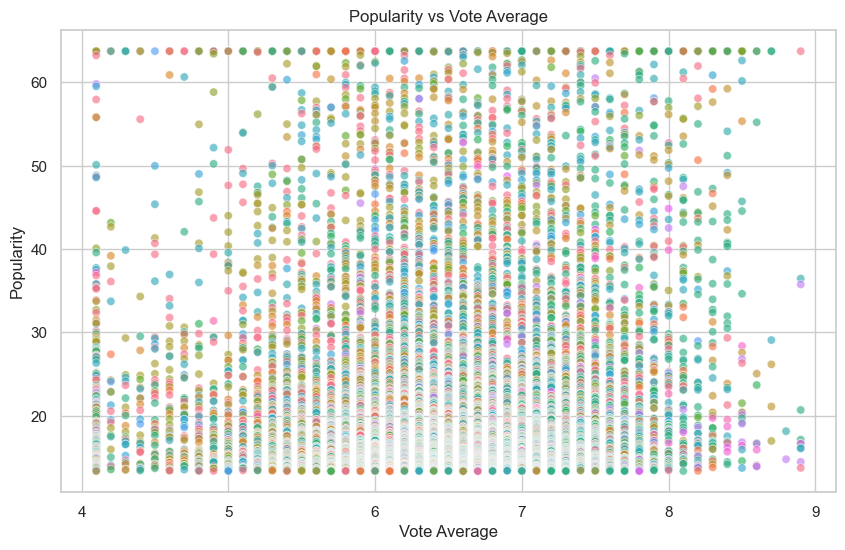

In [18]:
# Scatter plot: popularity vs vote average
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=eda_df,
    x="vote_average",
    y="popularity",
    hue="primary_genre",
    alpha=0.65,
    legend=False,
)
plt.title("Popularity vs Vote Average")
plt.xlabel("Vote Average")
plt.ylabel("Popularity")
plt.show()

**Observation:** Popularity and rating do not move together strongly. A movie can be popular without having the highest rating.

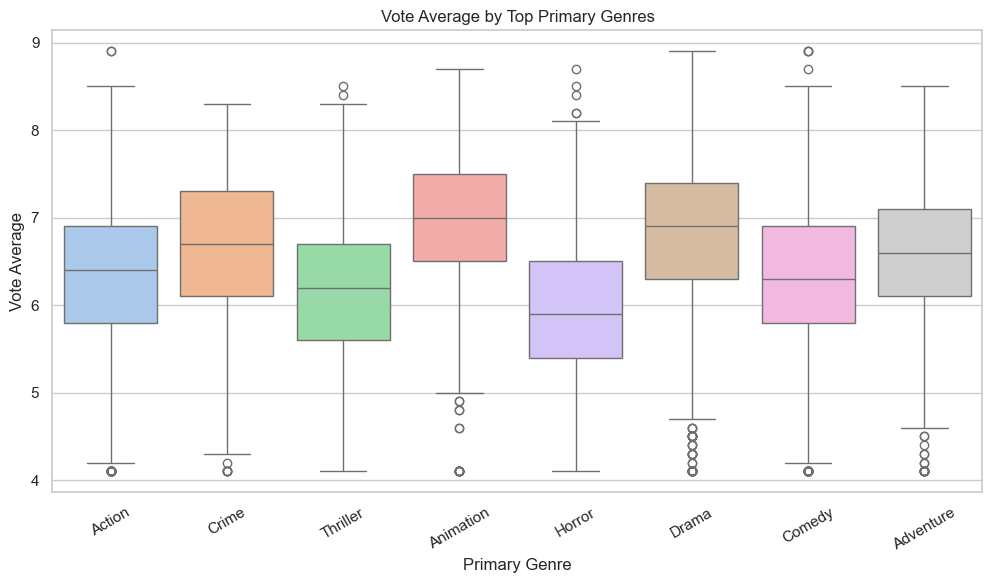

In [19]:
# Boxplot: vote average by top primary genres
top_primary_genres = eda_df["primary_genre"].value_counts().head(8).index
top_primary_df = eda_df[eda_df["primary_genre"].isin(top_primary_genres)]

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=top_primary_df,
    x="primary_genre",
    y="vote_average",
    hue="primary_genre",
    palette="pastel",
    legend=False,
)
plt.title("Vote Average by Top Primary Genres")
plt.xlabel("Primary Genre")
plt.ylabel("Vote Average")
plt.xticks(rotation=30)
plt.show()

**Observation:** Ratings vary by genre. Some genres have a wider spread, which means audience response is less consistent.

## 10. Correlation Analysis

Correlation matrix:


,popularity,vote_count,vote_average,release_year,release_month,title_length,overview_length
popularity,1.000000,0.409767,0.131218,0.243337,-0.018306,0.046443,-0.018082
vote_count,0.409767,1.000000,0.279368,-0.044400,0.045312,-0.139030,-0.029749
vote_average,0.131218,0.279368,1.000000,-0.165782,0.091603,0.077452,0.023063
release_year,0.243337,-0.044400,-0.165782,1.000000,-0.046908,0.013825,-0.063471
release_month,-0.018306,0.045312,0.091603,-0.046908,1.000000,0.011272,-0.026079
title_length,0.046443,-0.139030,0.077452,0.013825,0.011272,1.000000,0.117597
overview_length,-0.018082,-0.029749,0.023063,-0.063471,-0.026079,0.117597,1.000000


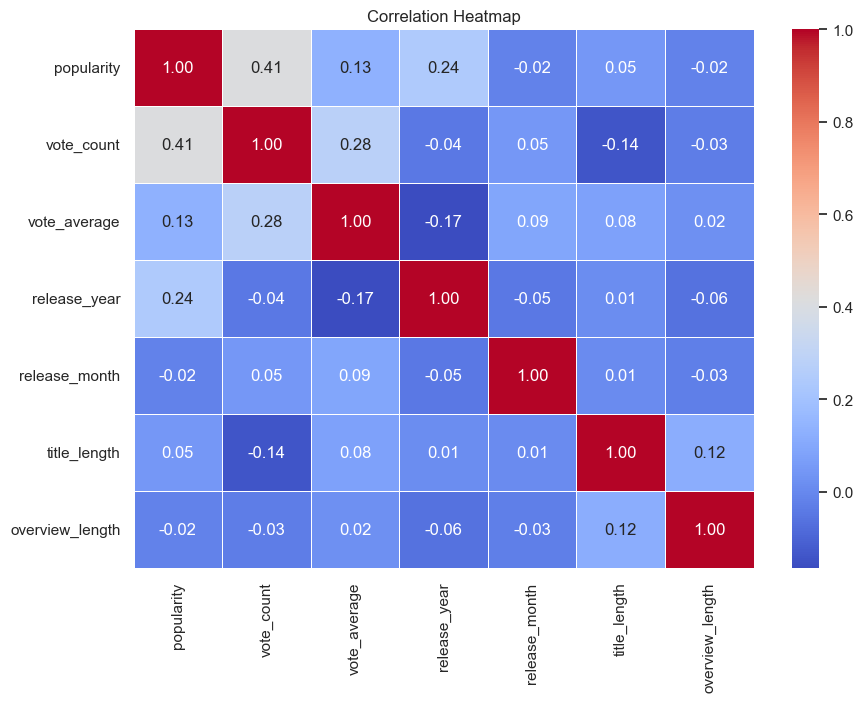

In [20]:
# Select numerical columns for correlation analysis
correlation_columns = [
    "popularity",
    "vote_count",
    "vote_average",
    "release_year",
    "release_month",
    "title_length",
    "overview_length",
]

correlation_matrix = eda_df[correlation_columns].corr()

print("Correlation matrix:")
display(correlation_matrix)

# Heatmap: correlation analysis
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

**Correlation notes:**

- A positive correlation means two variables move in the same direction.
- A negative correlation means one variable tends to increase when the other decreases.
- A value close to 1 or -1 shows a strong relationship.
- A value close to 0 shows a weak relationship.

Most relationships are weak. Popularity is more connected with vote count than with vote average.

## 11. Key Insights

In [21]:
# Generate simple insight values from the cleaned data
most_common_genre = all_genres.value_counts().idxmax()
most_common_genre_count = all_genres.value_counts().max()

most_common_language = eda_df["original_language"].value_counts().idxmax()
most_common_language_count = eda_df["original_language"].value_counts().max()

peak_year = yearly_movies.loc[yearly_movies["movie_count"].idxmax(), "release_year"]
peak_year_count = yearly_movies["movie_count"].max()

popularity_rating_corr = eda_df["popularity"].corr(eda_df["vote_average"])
popularity_vote_count_corr = eda_df["popularity"].corr(eda_df["vote_count"])

top_popular_movies = movies.sort_values("popularity", ascending=False)[
    ["title", "popularity", "vote_average", "vote_count", "genre"]
].head(5)

qualified_top_rated = movies[movies["vote_count"] >= 500].sort_values("vote_average", ascending=False)[
    ["title", "vote_average", "vote_count", "genre"]
].head(5)

print("Most common genre:", most_common_genre, "with", most_common_genre_count, "movies")
print("Most common original language:", most_common_language, "with", most_common_language_count, "movies")
print("Year with the most movie releases:", int(peak_year), "with", int(peak_year_count), "movies")
print("Correlation between popularity and vote average:", round(popularity_rating_corr, 3))
print("Correlation between popularity and vote count:", round(popularity_vote_count_corr, 3))

print("\nTop 5 movies by popularity:")
display(top_popular_movies)

print("Top 5 highly rated movies with at least 500 votes:")
display(qualified_top_rated)

Most common genre: Drama with 3744 movies
Most common original language: en with 7569 movies
Year with the most movie releases: 2021 with 714 movies
Correlation between popularity and vote average: 0.131
Correlation between popularity and vote count: 0.41

Top 5 movies by popularity:


,title,popularity,vote_average,vote_count,genre
0,Spider-Man: No Way Home,5083.954,8.3,8940.0,"Action, Adventure, Science Fiction"
1,The Batman,3827.658,8.1,1151.0,"Crime, Mystery, Thriller"
2,No Exit,2618.087,6.3,122.0,Thriller
3,Encanto,2402.201,7.7,5076.0,"Animation, Comedy, Family, Fantasy"
4,The King's Man,1895.511,7.0,1793.0,"Action, Adventure, Thriller, War"


Top 5 highly rated movies with at least 500 votes:


,title,vote_average,vote_count,genre
609,The Godfather,8.7,15614.0,"Drama, Crime"
657,The Shawshank Redemption,8.7,20911.0,"Drama, Crime"
3156,Dilwale Dulhania Le Jayenge,8.7,3474.0,"Comedy, Drama, Romance"
4196,Gabriel's Inferno Part III,8.6,946.0,"Romance, Comedy"
1327,Schindler's List,8.6,12474.0,"Drama, History, War"


**Key insights:**

- Drama is one of the most common genres in the dataset.
- English is the most common original language.
- Movie releases increased strongly in recent decades, with a visible rise after the 2000s.
- Popularity and vote average have a weak relationship, so a popular movie is not always highly rated.
- Vote count has a stronger relationship with popularity than vote average does.
- Action, animation, and science fiction related movies tend to perform well in average popularity.
- Some older classic movies have very high ratings when we filter for movies with a reasonable number of votes.

## 12. Conclusion

In this project, I completed an Exploratory Data Analysis of the MovieDB dataset using Python, Pandas, NumPy, Matplotlib, and Seaborn.

I loaded the data, checked its structure, cleaned missing and invalid values, removed duplicates, converted columns to the correct data types, handled outliers, and created simple features such as release year, release month, title length, and overview length.

The analysis showed that popularity is unevenly distributed, English-language movies dominate the dataset, and genres such as Drama, Comedy, Action, and Thriller appear frequently. Movie releases also increased in recent decades.

Overall, this project shows basic data cleaning, preprocessing, visualization, correlation analysis, and insight generation skills in a clear internship-ready format.